In [46]:
import itertools
import pandas as pd
import numpy as np

from aeon.datasets.tsc_datasets import multivariate

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

df = pd.read_excel("resultados_finais/ResultadosFinais.xlsx")
df_baseline = pd.read_csv("uea_benchmark (1).csv")

print(f"Total de registros: {len(df)}")
print(f"Datasets únicos: {len(df['dataset'].unique())}")
print(f"Baseline UEA - Datasets: {len(df_baseline)}")
print(f"Colunas disponíveis: {list(df.columns)}")
print("\nPrimeiras linhas:")
df.head()

Total de registros: 954
Datasets únicos: 26
Baseline UEA - Datasets: 30
Colunas disponíveis: ['dataset', 'representation', 'representation_transform_time', 'concatenation_type', 'accuracy', 'convolution_algorithm', 'convolution_time', 'classification_algorithm', 'train_time', 'validation_time']

Primeiras linhas:


,dataset,representation,representation_transform_time,concatenation_type,accuracy,convolution_algorithm,convolution_time,classification_algorithm,train_time,validation_time
0,AtrialFibrillation,CWT,0.134481,pre_transform,0.400000,NaN,0.000000e+00,Ridge,0.010381,0.000531
1,AtrialFibrillation,CWT,0.134481,pre_transform,0.200000,Rocket,1.027527e+14,Ridge,0.008690,0.000968
2,AtrialFibrillation,CWT,0.134481,pre_transform,0.333333,MiniRocket,4.693351e-01,Ridge,0.007075,0.000921
3,AtrialFibrillation,CWT,0.092987,post_transform,0.333333,NaN,0.000000e+00,Ridge,0.001601,0.000326
4,AtrialFibrillation,CWT,0.092987,post_transform,0.333333,Rocket,5.019178e-01,Ridge,0.016172,0.001501


In [48]:
representations = df['representation'].unique()
concatenation_types = df['concatenation_type'].unique()
convolution_algorithms = df['convolution_algorithm'].unique()
classification_algorithms = df['classification_algorithm'].unique()

print("Representações:", representations)
print("Concatenação:", concatenation_types)
print("Convolução:", convolution_algorithms)
print("Classificação:", classification_algorithms)

Representações: ['CWT' 'RP' 'MTF' 'GASF' 'GADF' 'FIRTS']
Concatenação: ['pre_transform' 'post_transform']
Convolução: [nan 'Rocket' 'MiniRocket']
Classificação: ['Ridge']


In [49]:
df

,dataset,representation,representation_transform_time,concatenation_type,accuracy,convolution_algorithm,convolution_time,classification_algorithm,train_time,validation_time
0,AtrialFibrillation,CWT,0.134481,pre_transform,0.400000,NaN,0.000000e+00,Ridge,0.010381,0.000531
1,AtrialFibrillation,CWT,0.134481,pre_transform,0.200000,Rocket,1.027527e+14,Ridge,0.008690,0.000968
2,AtrialFibrillation,CWT,0.134481,pre_transform,0.333333,MiniRocket,4.693351e-01,Ridge,0.007075,0.000921
3,AtrialFibrillation,CWT,0.092987,post_transform,0.333333,NaN,0.000000e+00,Ridge,0.001601,0.000326
4,AtrialFibrillation,CWT,0.092987,post_transform,0.333333,Rocket,5.019178e-01,Ridge,0.016172,0.001501
...,...,...,...,...,...,...,...,...,...,...
949,StandWalkJump,FIRTS,0.113150,pre_transform,0.600000,Rocket,1.940745e+00,Ridge,0.002347,0.000405
950,StandWalkJump,FIRTS,0.113150,pre_transform,0.733333,MiniRocket,1.250262e+00,Ridge,0.001839,0.000340
951,StandWalkJump,FIRTS,0.158670,post_transform,0.400000,NaN,0.000000e+00,Ridge,0.001509,0.000254
952,StandWalkJump,FIRTS,0.158670,post_transform,0.533333,Rocket,5.131276e-01,Ridge,0.002213,0.000409


## Análise de Performance por Dataset

Boxplot mostrando a distribuição de acurácia para cada dataset. Identifica quais datasets são naturalmente mais fáceis ou difíceis de classificar, independentemente da configuração utilizada.

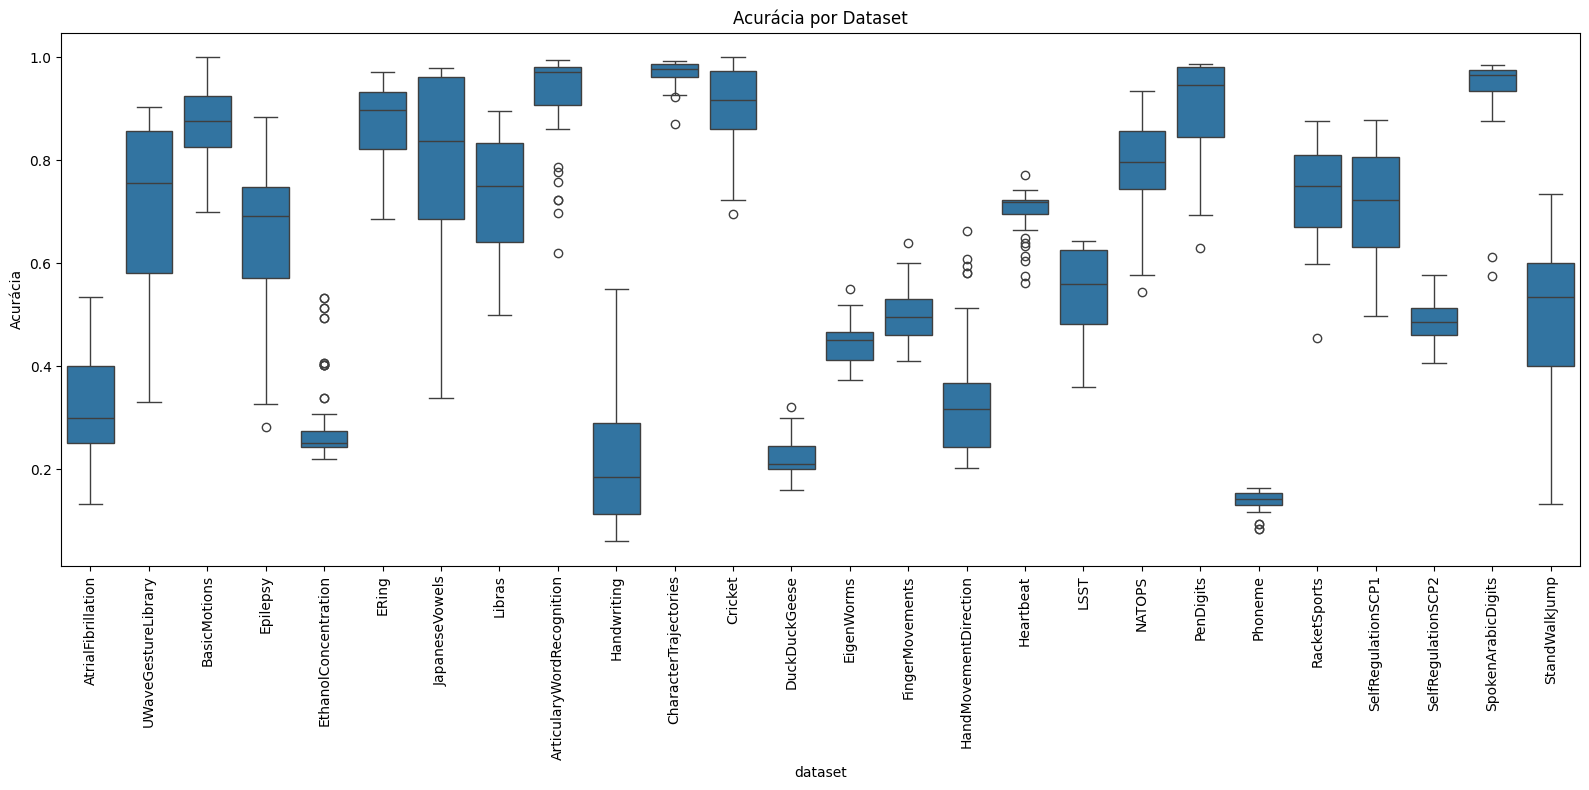

In [50]:
plt.figure(figsize=(16, 8))
sns.boxplot(x="dataset", y="accuracy", data=df)
plt.title("Acurácia por Dataset")
plt.ylabel("Acurácia")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Performance por Representação Visual

Comparação da acurácia entre as seis representações visuais testadas: CWT, GASF, GADF, RP, MTF e FIRTS.

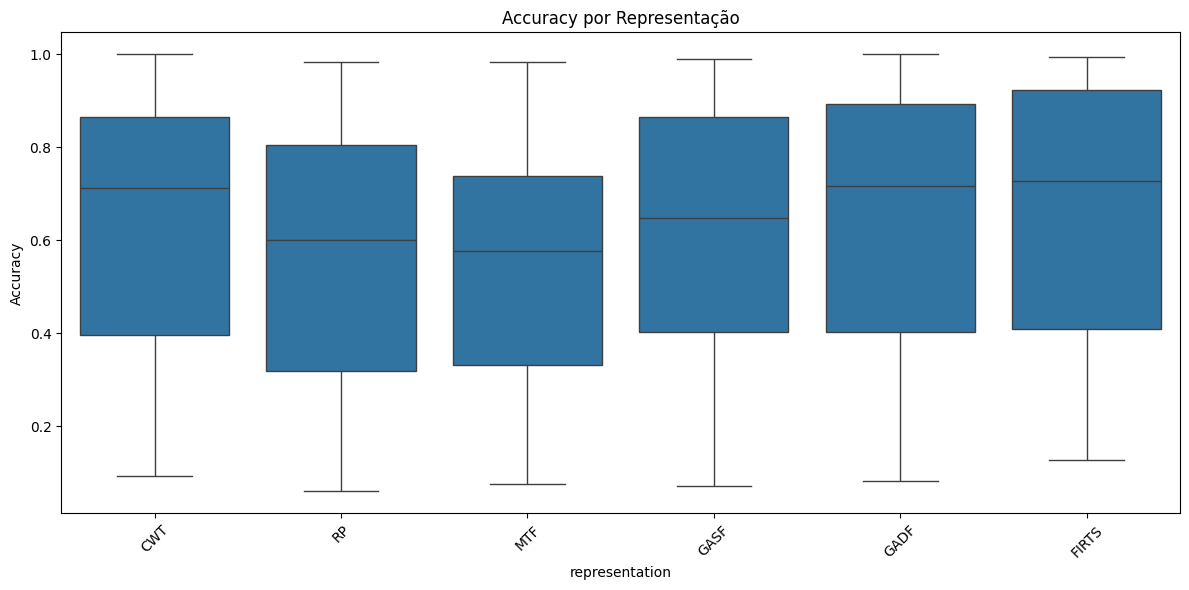

In [51]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="representation", y="accuracy", data=df)
plt.title("Accuracy por Representação")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

## Performance por Tipo de Concatenação

Comparação entre as estratégias de concatenar representações antes (pre_transform) ou depois (post_transform) da aplicação dos algoritmos Rocket/MiniRocket.

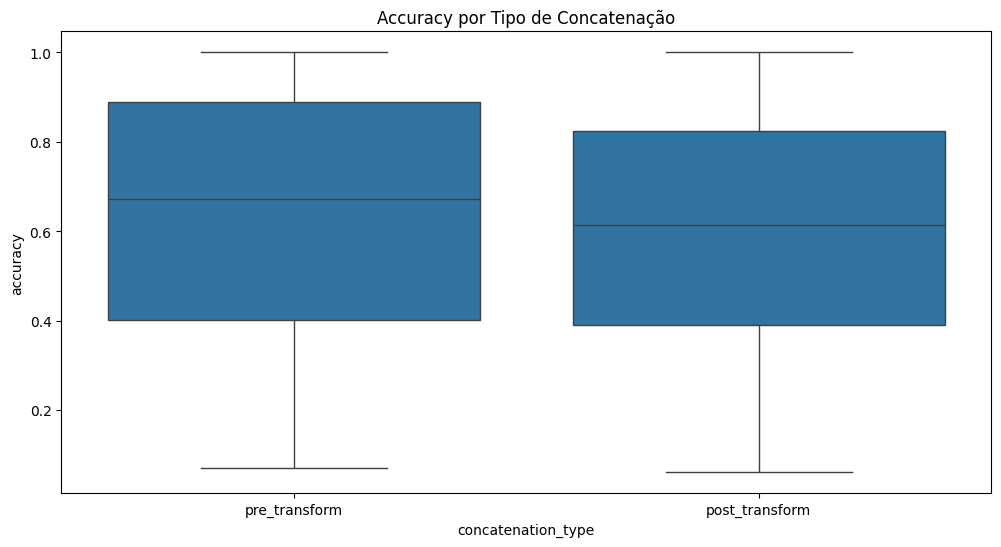

In [52]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="concatenation_type", y="accuracy", data=df)
plt.title("Accuracy por Tipo de Concatenação")
plt.show()

## Performance por Algoritmo de Convolução

Comparação entre Rocket, MiniRocket e classificação direta (Only Ridge)

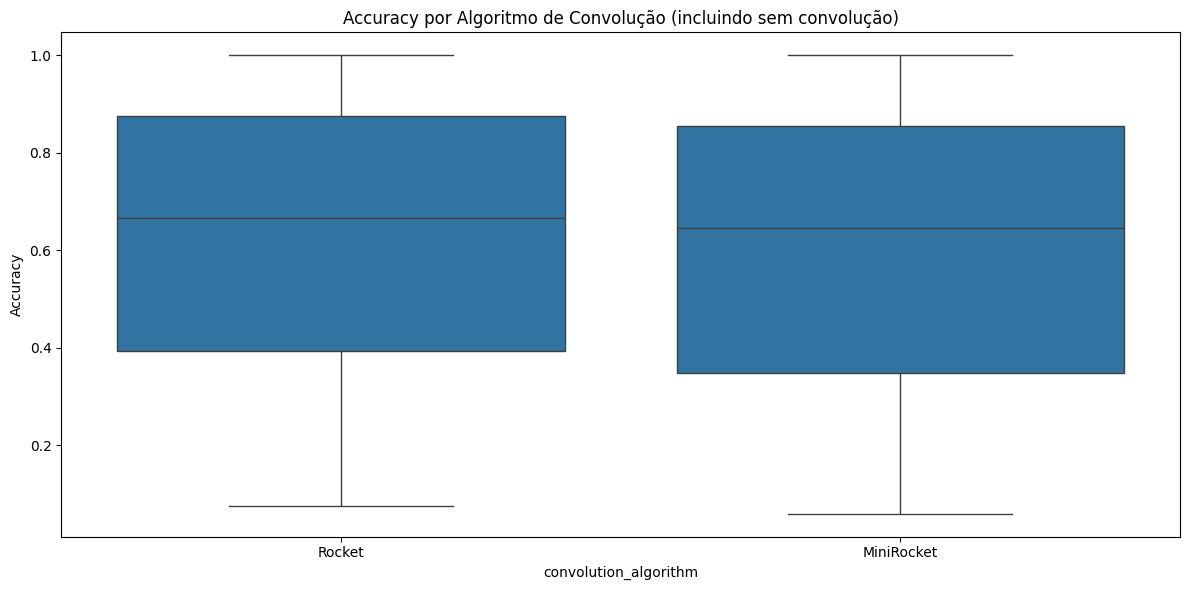

Estatísticas por algoritmo de convolução:
                       count    mean     std     min  max
convolution_algorithm                                    
MiniRocket               318  0.6030  0.2782  0.0600  1.0
Rocket                   318  0.6214  0.2763  0.0765  1.0


In [67]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="convolution_algorithm", y="accuracy", data=df)
plt.title("Accuracy por Algoritmo de Convolução (incluindo sem convolução)")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

print("Estatísticas por algoritmo de convolução:")
conv_stats = df.groupby('convolution_algorithm')['accuracy'].agg(['count', 'mean', 'std', 'min', 'max'])
print(conv_stats.round(4))

## Impacto das Estratégias de Concatenação

Testamos duas estratégias: concatenar as representações antes da transformação (pre_transform) ou depois (post_transform).

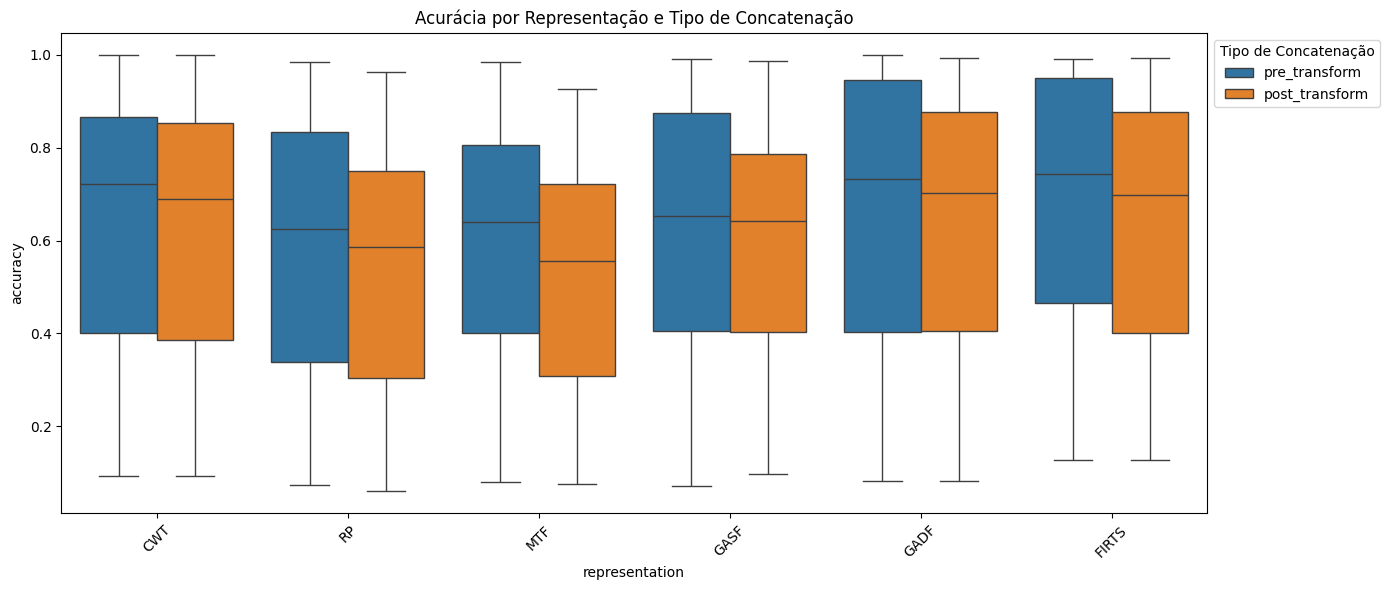

In [54]:
plt.figure(figsize=(14, 6))
sns.boxplot(x="representation", y="accuracy", hue="concatenation_type", data=df)
plt.legend(title='Tipo de Concatenação', loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Acurácia por Representação e Tipo de Concatenação")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interação: Representação × Algoritmo de Convolução

Análise da performance de cada representação visual combinada com cada algoritmo de transformação de características (Rocket, MiniRocket, Only Ridge).

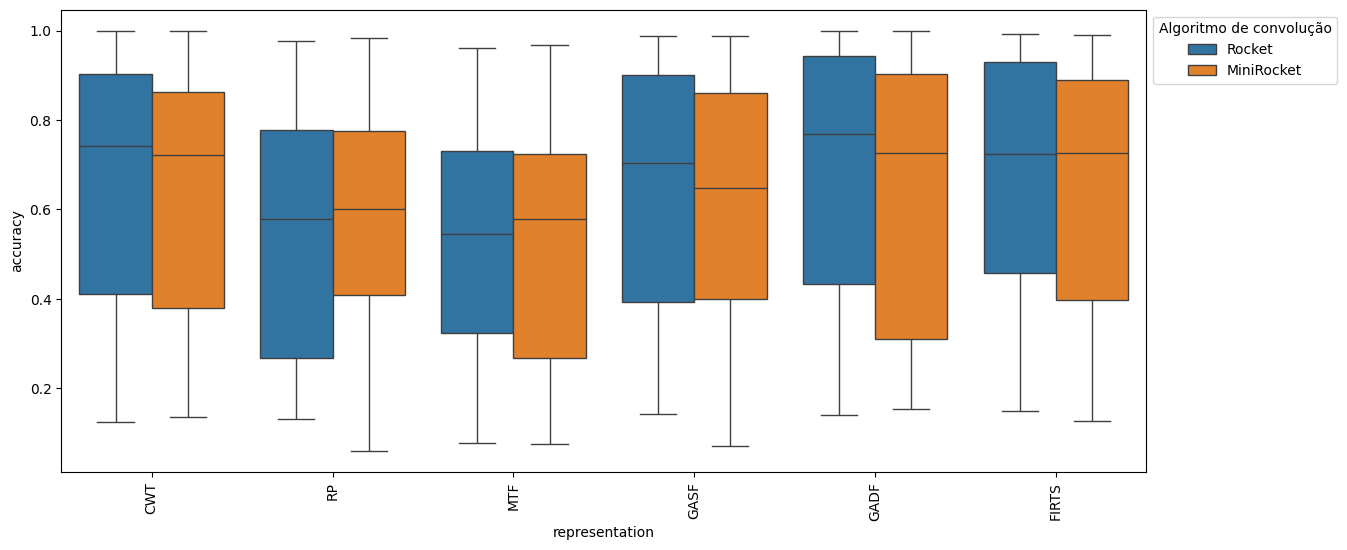

In [55]:
plt.figure(figsize=(14, 6))
plt.xticks(rotation=90)

sns.boxplot(x="representation", y="accuracy", hue="convolution_algorithm", data=df)

plt.legend(title='Algoritmo de convolução', loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

## Interação: Concatenação × Algoritmo de Convolução

Análise combinada das estratégias de concatenação (pre/post_transform) com os algoritmos de transformação (Rocket, MiniRocket, Only Ridge).

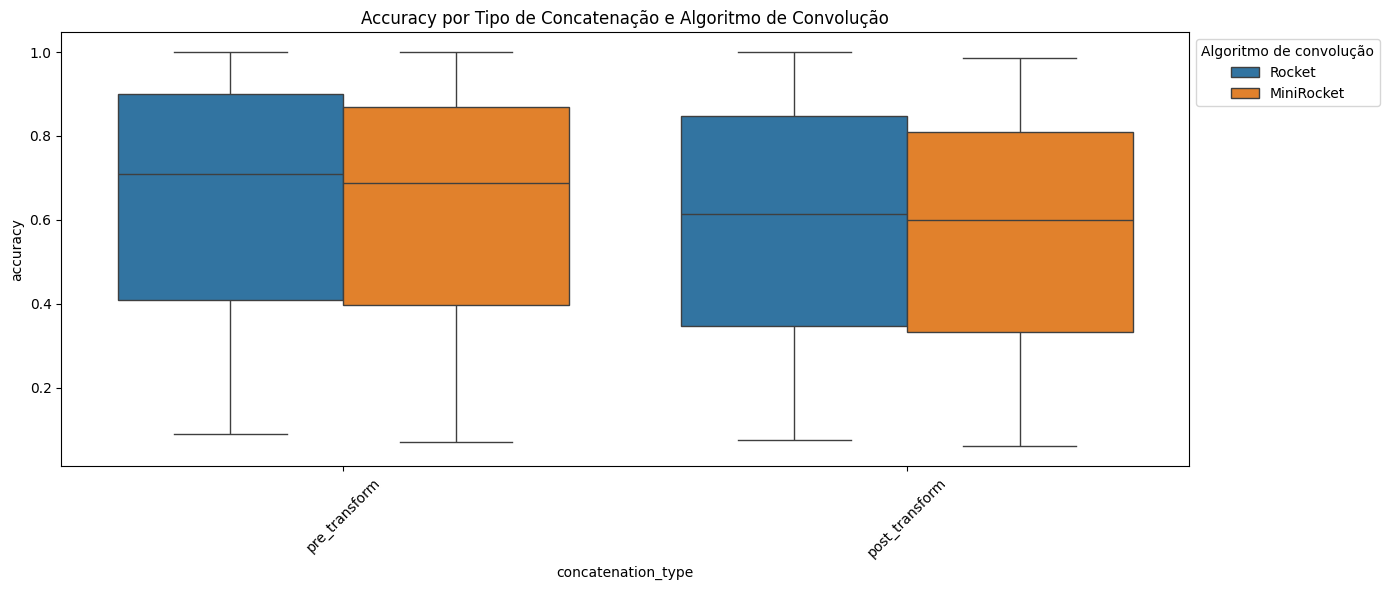

In [56]:
plt.figure(figsize=(14, 6))
plt.xticks(rotation=45)

sns.boxplot(x="concatenation_type", y="accuracy", hue="convolution_algorithm", data=df)

plt.legend(title='Algoritmo de convolução', loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Accuracy por Tipo de Concatenação e Algoritmo de Convolução")
plt.tight_layout()
plt.show()

## Performance por Algoritmo de Classificação

Comparação entre os classificadores utilizados após a extração de características. Ridge Classifier é usado com Rocket/MiniRocket, enquanto outros classificadores são testados com Only Ridge.

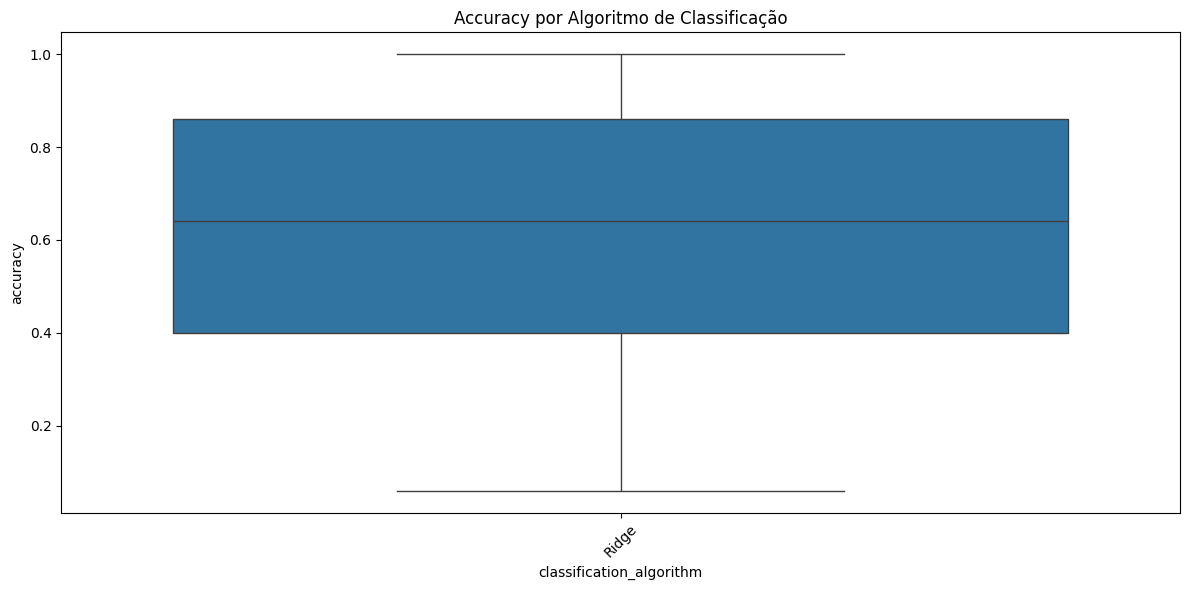

In [57]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="classification_algorithm", y="accuracy", data=df)
plt.title("Accuracy por Algoritmo de Classificação")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análise de Tempos de Execução

Tempo necessário para transformar as séries temporais em representações visuais.

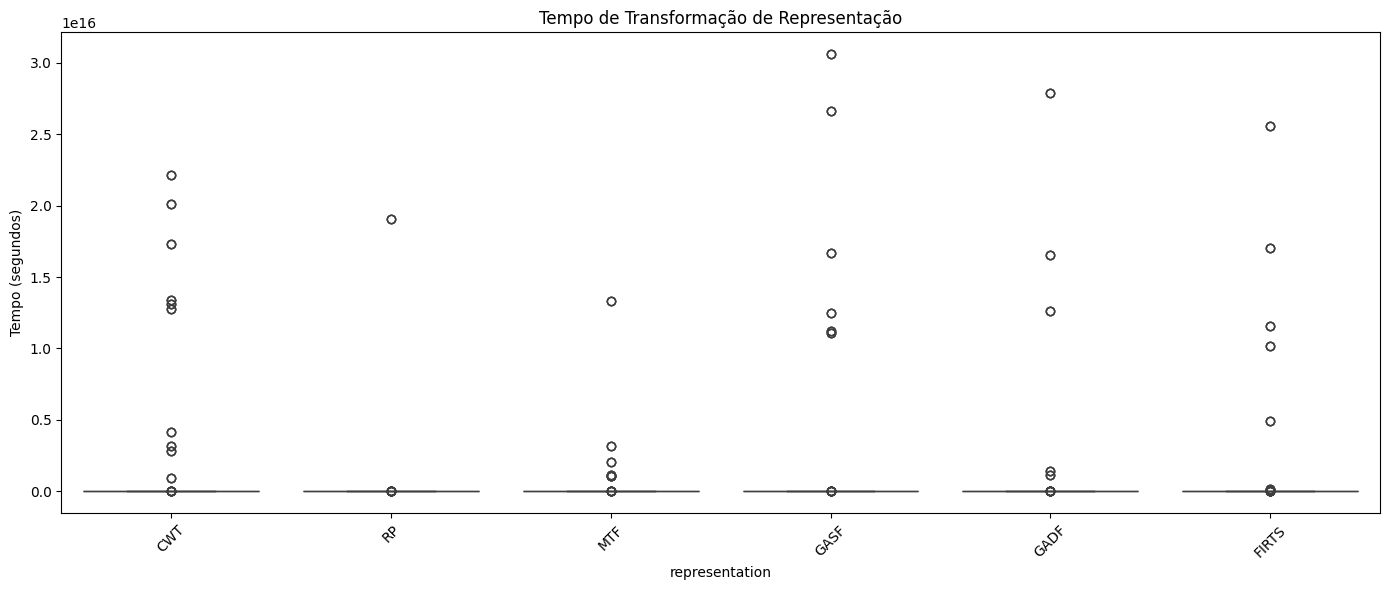

In [58]:
plt.figure(figsize=(14, 6))
sns.boxplot(x="representation", y="representation_transform_time", data=df)
plt.title("Tempo de Transformação de Representação")
plt.xticks(rotation=45)
plt.ylabel("Tempo (segundos)")
plt.tight_layout()
plt.show()

## Estatísticas Resumidas

Tabelas com médias, desvios-padrão e outras estatísticas descritivas para cada configuração testada. Inclui identificação da melhor configuração para cada dataset.

In [59]:
print("=== ACCURACY POR REPRESENTAÇÃO ===")
accuracy_by_rep = df.groupby('representation')['accuracy'].agg(['mean', 'std', 'min', 'max', 'count'])
print(accuracy_by_rep.round(4))

print("\n=== ACCURACY POR ALGORITMO DE CONVOLUÇÃO ===")
accuracy_by_conv = df.groupby('convolution_algorithm')['accuracy'].agg(['mean', 'std', 'min', 'max', 'count'])
print(accuracy_by_conv.round(4))

print("\n=== ACCURACY POR TIPO DE CONCATENAÇÃO ===")
accuracy_by_concat = df.groupby('concatenation_type')['accuracy'].agg(['mean', 'std', 'min', 'max', 'count'])
print(accuracy_by_concat.round(4))

print("\n=== MELHOR CONFIGURAÇÃO POR DATASET ===")
best_config = df.loc[df.groupby('dataset')['accuracy'].idxmax()][['dataset', 'representation', 'concatenation_type', 'convolution_algorithm', 'accuracy']]
print(best_config.sort_values('accuracy', ascending=False))

=== ACCURACY POR REPRESENTAÇÃO ===
                  mean     std     min     max  count
representation                                       
CWT             0.6304  0.2734  0.0928  1.0000    159
FIRTS           0.6466  0.2853  0.1271  0.9933    159
GADF            0.6489  0.2834  0.0833  1.0000    159
GASF            0.6153  0.2693  0.0706  0.9903    159
MTF             0.5535  0.2581  0.0753  0.9833    159
RP              0.5751  0.2653  0.0600  0.9833    159

=== ACCURACY POR ALGORITMO DE CONVOLUÇÃO ===
                         mean     std     min  max  count
convolution_algorithm                                    
MiniRocket             0.6030  0.2782  0.0600  1.0    318
Rocket                 0.6214  0.2763  0.0765  1.0    318

=== ACCURACY POR TIPO DE CONCATENAÇÃO ===
                      mean     std     min  max  count
concatenation_type                                    
post_transform      0.5933  0.2661  0.0600  1.0    468
pre_transform       0.6293  0.2810  0.0706  1.0

## Análise da Melhor Configuração

Foco na combinação Pre-Transform + Rocket, que apresentou os melhores resultados gerais. Análise detalhada da performance de cada representação visual nesta configuração específica.

Registros com pre_transform + Rocket: 162


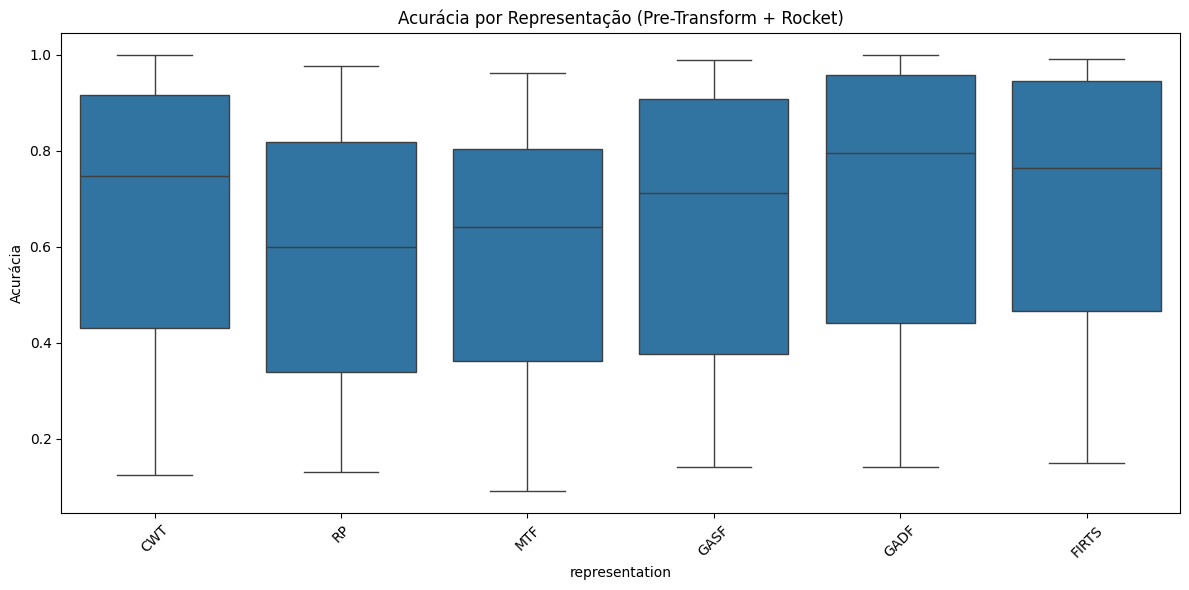

                count    mean     std     min     max
representation                                       
CWT                27  0.6597  0.2931  0.1245  1.0000
FIRTS              27  0.6725  0.2918  0.1498  0.9903
GADF               27  0.6762  0.3001  0.1408  1.0000
GASF               27  0.6487  0.2812  0.1419  0.9882
MTF                27  0.5883  0.2690  0.0906  0.9617
RP                 27  0.5854  0.2785  0.1306  0.9770


In [ ]:
df_pre_rocket = df[(df['concatenation_type'] == 'pre_transform') & 
                   (df['convolution_algorithm'] == 'Rocket')]

print(f"Registros com pre_transform + Rocket: {len(df_pre_rocket)}")

plt.figure(figsize=(12, 6))
sns.boxplot(x="representation", y="accuracy", data=df_pre_rocket)
plt.title("Acurácia por Representação (Pre-Transform + Rocket)")
plt.xticks(rotation=45)
plt.ylabel("Acurácia")
plt.tight_layout()
plt.show()

rep_stats = df_pre_rocket.groupby('representation')['accuracy'].agg(['count', 'mean', 'std', 'min', 'max'])
print(rep_stats.round(4))

## Comparação com Baseline UEA

Scatterplots comparando cada representação visual (com Pre-Transform + Rocket) contra o baseline UEA (DTWD). Pontos acima da diagonal vermelha indicam datasets onde nossa abordagem supera o baseline.

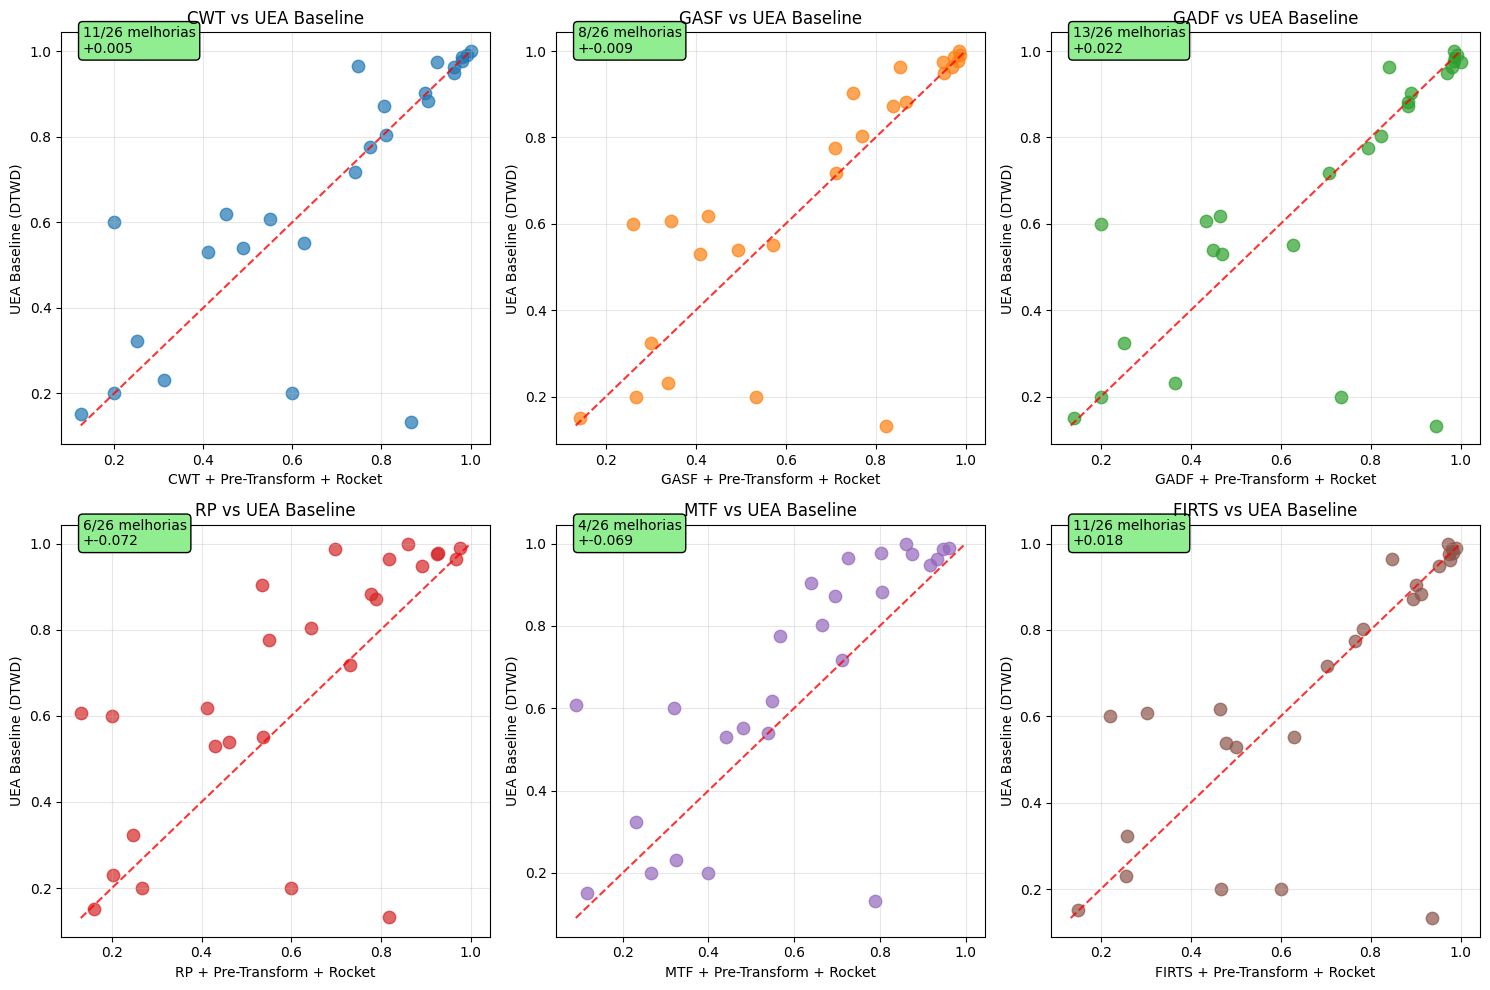


Resumo das Comparações com UEA Baseline:
  Representação  Datasets  Melhorias  Taxa_Melhorias  Melhoria_Media
2          GADF        26         13           0.500           0.022
0           CWT        26         11           0.423           0.005
5         FIRTS        26         11           0.423           0.018
1          GASF        26          8           0.308          -0.009
3            RP        26          6           0.231          -0.072
4           MTF        26          4           0.154          -0.069


In [61]:
def compare_with_uea_baseline(representation_name, baseline_column='unnormalised_dtwd'):
    our_results = df_pre_rocket[df_pre_rocket['representation'] == representation_name]
    our_best = our_results.groupby('dataset')['accuracy'].max().reset_index()
    
    baseline_results = df_baseline[['dataset', baseline_column]].copy()
    baseline_results.columns = ['dataset', 'baseline_accuracy']
    
    comparison = our_best.merge(baseline_results, on='dataset', how='inner')
    return comparison

representations = ['CWT', 'GASF', 'GADF', 'RP', 'MTF', 'FIRTS']
baseline_col = 'unnormalised_dtwd'  # Usando DTWD como baseline principal

plt.figure(figsize=(15, 10))

results_summary = []

for i, rep in enumerate(representations, 1):
    plt.subplot(2, 3, i)
    
    comparison = compare_with_uea_baseline(rep, baseline_col)
    
    if len(comparison) > 0:
        plt.scatter(comparison['accuracy'], comparison['baseline_accuracy'], 
                   alpha=0.7, s=80, color=f'C{i-1}')
        
        min_acc = min(comparison['accuracy'].min(), comparison['baseline_accuracy'].min())
        max_acc = max(comparison['accuracy'].max(), comparison['baseline_accuracy'].max())
        plt.plot([min_acc, max_acc], [min_acc, max_acc], 'r--', alpha=0.8)
        
        plt.xlabel(f'{rep} + Pre-Transform + Rocket')
        plt.ylabel('UEA Baseline (DTWD)')
        plt.title(f'{rep} vs UEA Baseline')
        plt.grid(True, alpha=0.3)
        
        wins = (comparison['accuracy'] > comparison['baseline_accuracy']).sum()
        total = len(comparison)
        improvement = comparison['accuracy'].mean() - comparison['baseline_accuracy'].mean()
        
        plt.text(0.05, 0.95, f'{wins}/{total} melhorias\n+{improvement:.3f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
        
        results_summary.append({
            'Representação': rep,
            'Datasets': total,
            'Melhorias': wins,
            'Taxa_Melhorias': wins/total if total > 0 else 0,
            'Melhoria_Media': improvement
        })

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(results_summary)
print("\nResumo das Comparações com UEA Baseline:")
print(summary_df.sort_values('Taxa_Melhorias', ascending=False).round(3))

## Análise Completa de Combinações

Análise sistemática de todas as combinações possíveis de estratégias de concatenação (pre/post_transform) com algoritmos de transformação (Rocket, MiniRocket, Only Ridge). Compara performance entre todas as configurações testadas.

Algoritmos de convolução únicos nos dados:
convolution_algorithm
NaN           318
Rocket        318
MiniRocket    318
Name: count, dtype: int64

Algoritmos encontrados: ['Rocket', 'MiniRocket', 'Only Ridge']


/tmp/ipykernel_52096/610854713.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_52096/610854713.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_52096/610854713.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_52096/610854713.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_52096/610854713.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of t

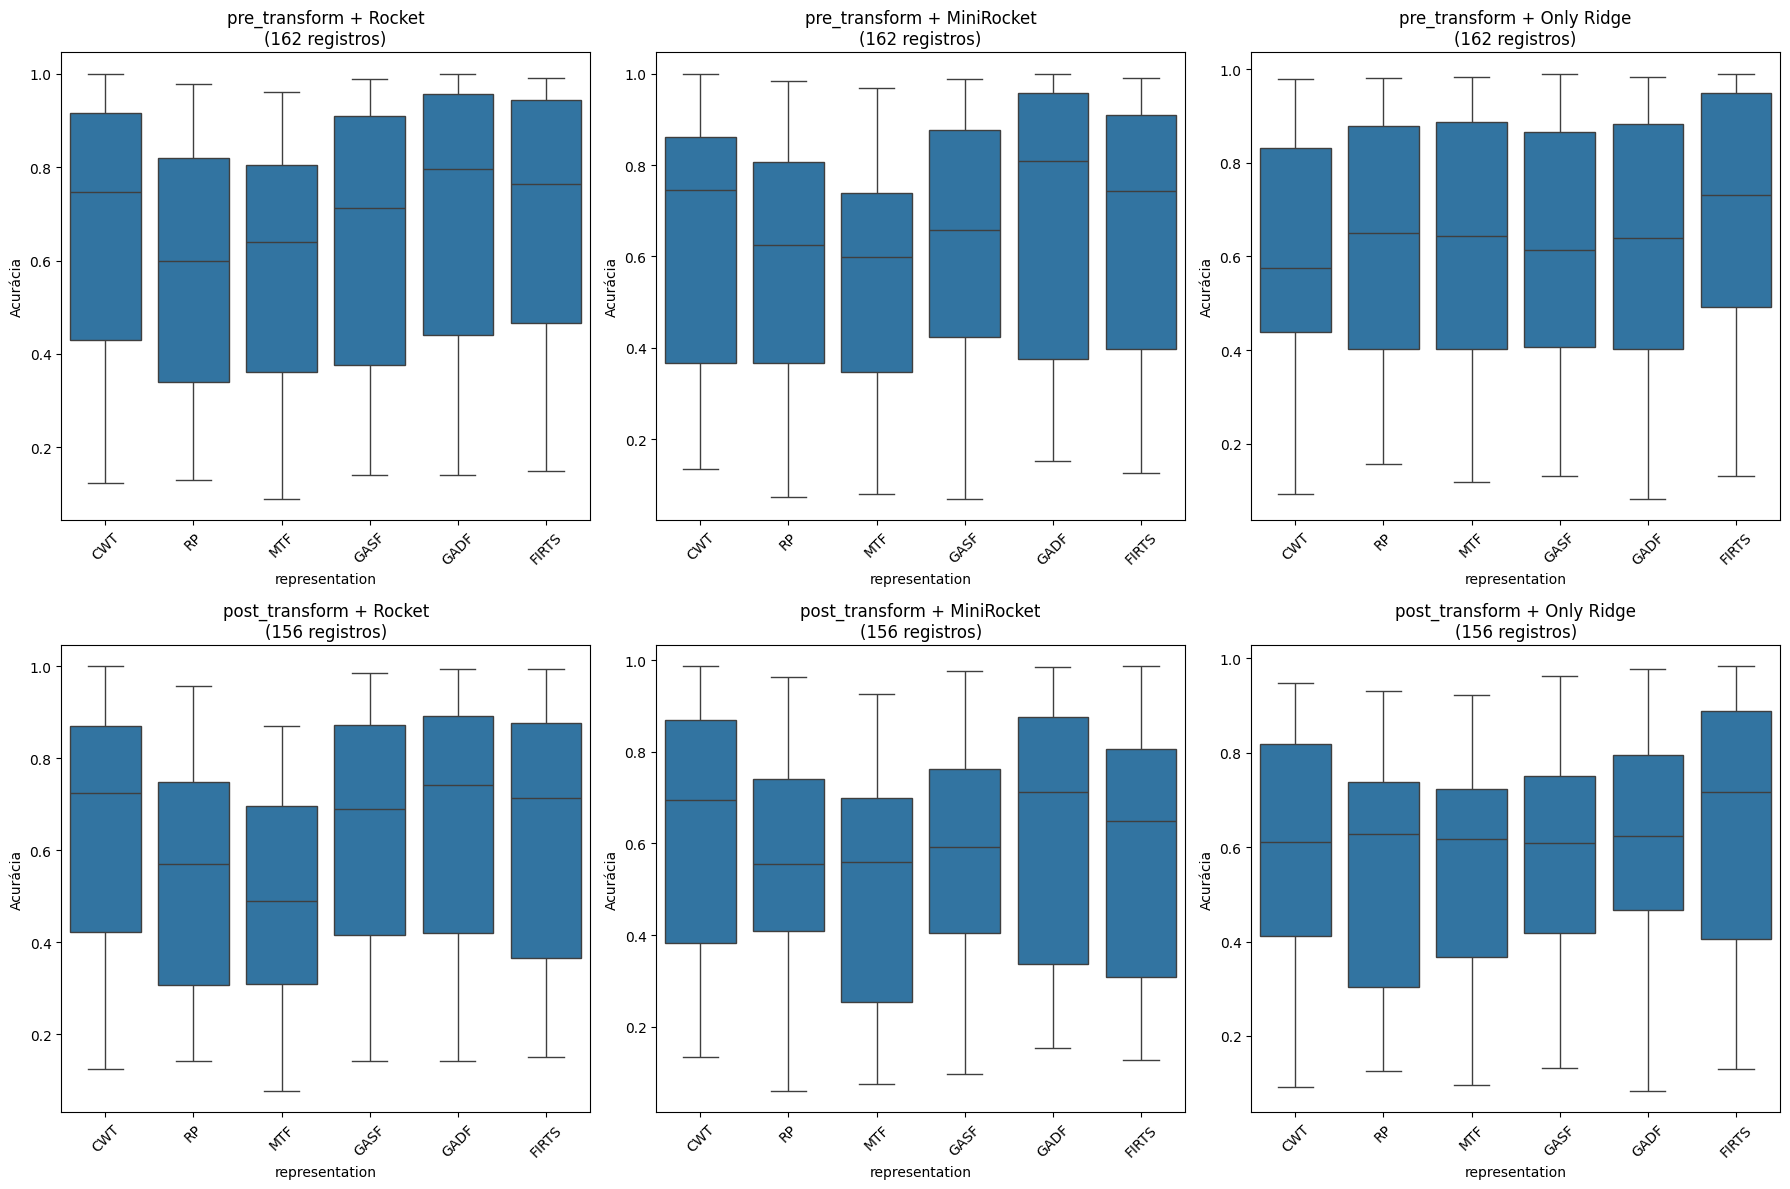


Resumo das Estatísticas por Combinação:
    Concatenacao  Convolucao Representacao  Count    Mean     Std
0  pre_transform      Rocket           CWT     27  0.6597  0.2931
1  pre_transform      Rocket         FIRTS     27  0.6725  0.2918
2  pre_transform      Rocket          GADF     27  0.6762  0.3001
3  pre_transform      Rocket          GASF     27  0.6487  0.2812
4  pre_transform      Rocket           MTF     27  0.5883  0.2690
5  pre_transform      Rocket            RP     27  0.5854  0.2785
6  pre_transform  MiniRocket           CWT     27  0.6284  0.2907
7  pre_transform  MiniRocket         FIRTS     27  0.6589  0.2943
8  pre_transform  MiniRocket          GADF     27  0.6724  0.3013
9  pre_transform  MiniRocket          GASF     27  0.6254  0.2898


In [ ]:
concatenation_types_all = ['pre_transform', 'post_transform']
convolution_algorithms_all = ['Rocket', 'MiniRocket', None]

print("Algoritmos de convolução únicos nos dados:")
unique_conv = df['convolution_algorithm'].value_counts(dropna=False)
print(unique_conv)

conv_algorithms_real = []
for alg in ['Rocket', 'MiniRocket']:
    if alg in df['convolution_algorithm'].values:
        conv_algorithms_real.append(alg)

only_ridge_exists = df['convolution_algorithm'].isna().any() or (df['convolution_algorithm'] == '').any()
if only_ridge_exists:
    conv_algorithms_real.append('Only Ridge')

print(f"\nAlgoritmos encontrados: {conv_algorithms_real}")

fig, axes = plt.subplots(len(concatenation_types_all), len(conv_algorithms_real), 
                        figsize=(18, 12))

if len(conv_algorithms_real) == 1:
    axes = axes.reshape(-1, 1)

combinations_stats = []

for i, concat_type in enumerate(concatenation_types_all):
    for j, conv_alg in enumerate(conv_algorithms_real):
        ax = axes[i, j]
        
        if conv_alg == 'Only Ridge':
            subset = df[(df['concatenation_type'] == concat_type) & 
                       (df['convolution_algorithm'].isna() | (df['convolution_algorithm'] == ''))]
        else:
            subset = df[(df['concatenation_type'] == concat_type) & 
                       (df['convolution_algorithm'] == conv_alg)]
        
        if len(subset) > 0:
            sns.boxplot(data=subset, x='representation', y='accuracy', ax=ax)
            ax.set_title(f'{concat_type} + {conv_alg}\n({len(subset)} registros)')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
            ax.set_ylabel('Acurácia')
            
            stats = subset.groupby('representation')['accuracy'].agg(['count', 'mean', 'std']).round(4)
            
            for rep in stats.index:
                combinations_stats.append({
                    'Concatenacao': concat_type,
                    'Convolucao': conv_alg,
                    'Representacao': rep,
                    'Count': stats.loc[rep, 'count'],
                    'Mean': stats.loc[rep, 'mean'],
                    'Std': stats.loc[rep, 'std']
                })
        else:
            ax.text(0.5, 0.5, 'Sem dados\ndisponíveis', 
                   ha='center', va='center', transform=ax.transAxes,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
            ax.set_title(f'{concat_type} + {conv_alg}\n(0 registros)')

plt.tight_layout()
plt.show()

combinations_df = pd.DataFrame(combinations_stats)
print("\nResumo das Estatísticas por Combinação:")
print(combinations_df.head(10))

## Ranking das Configurações

Ranking das melhores configurações considerando todas as combinações de concatenação, algoritmo de transformação e representação visual. Identifica quais configurações são mais efetivas.

In [ ]:
if len(combinations_df) > 0:
    ranking = combinations_df.sort_values('Mean', ascending=False)
    
    print("="*80)
    print("TOP 15 MELHORES CONFIGURAÇÕES (Concatenação + Convolução + Representação)")
    print("="*80)
    
    top_15 = ranking.head(15)
    for idx, row in top_15.iterrows():
        print(f"{idx+1:2d}. {row['Concatenacao']:15s} + {row['Convolucao']:12s} + {row['Representacao']:6s} → "
              f"Acurácia: {row['Mean']:.4f} ± {row['Std']:.4f} ({row['Count']} experimentos)")
    
    print("\n" + "="*80)
    print("COMPARAÇÃO ENTRE ESTRATÉGIAS DE CONCATENAÇÃO")
    print("="*80)
    
    # comparação pre vs post transform para cada algoritmo de convolução
    for conv_alg in conv_algorithms_real:
        print(f"\n--- {conv_alg} ---")
        
        pre_data = combinations_df[(combinations_df['Convolucao'] == conv_alg) & 
                                  (combinations_df['Concatenacao'] == 'pre_transform')]
        post_data = combinations_df[(combinations_df['Convolucao'] == conv_alg) & 
                                   (combinations_df['Concatenacao'] == 'post_transform')]
        
        if len(pre_data) > 0 and len(post_data) > 0:
            pre_mean = pre_data['Mean'].mean()
            post_mean = post_data['Mean'].mean()
            
            print(f"Pre-transform média:  {pre_mean:.4f}")
            print(f"Post-transform média: {post_mean:.4f}")
            print(f"Diferença (pre - post): {pre_mean - post_mean:+.4f}")
            
            if pre_mean > post_mean:
                print("✓ Pre-transform é melhor")
            else:
                print("✓ Post-transform é melhor")
        else:
            print("Dados insuficientes para comparação")

    print("\n" + "="*80)
    print("COMPARAÇÃO ENTRE ALGORITMOS DE CONVOLUÇÃO")
    print("="*80)
    
    for concat_type in concatenation_types_all:
        print(f"\n--- {concat_type} ---")
        
        concat_data = combinations_df[combinations_df['Concatenacao'] == concat_type]
        if len(concat_data) > 0:
            conv_comparison = concat_data.groupby('Convolucao')['Mean'].agg(['count', 'mean', 'std']).round(4)
            conv_comparison = conv_comparison.sort_values('mean', ascending=False)
            
            print("Ranking por algoritmo de convolução:")
            for i, (conv_alg, stats) in enumerate(conv_comparison.iterrows(), 1):
                print(f"  {i}. {conv_alg:12s}: {stats['mean']:.4f} ± {stats['std']:.4f} "
                      f"({stats['count']} configurações)")

else:
    print("Nenhuma combinação encontrada nos dados.")

TOP 15 MELHORES CONFIGURAÇÕES (Concatenação + Convolução + Representação)
 3. pre_transform   + Rocket       + GADF   → Acurácia: 0.6762 ± 0.3001 (27 experimentos)
 2. pre_transform   + Rocket       + FIRTS  → Acurácia: 0.6725 ± 0.2918 (27 experimentos)
 9. pre_transform   + MiniRocket   + GADF   → Acurácia: 0.6724 ± 0.3013 (27 experimentos)
14. pre_transform   + Only Ridge   + FIRTS  → Acurácia: 0.6722 ± 0.2841 (27 experimentos)
21. post_transform  + Rocket       + GADF   → Acurácia: 0.6696 ± 0.2788 (26 experimentos)
 1. pre_transform   + Rocket       + CWT    → Acurácia: 0.6597 ± 0.2931 (27 experimentos)
 8. pre_transform   + MiniRocket   + FIRTS  → Acurácia: 0.6589 ± 0.2943 (27 experimentos)
19. post_transform  + Rocket       + CWT    → Acurácia: 0.6581 ± 0.2800 (26 experimentos)
 4. pre_transform   + Rocket       + GASF   → Acurácia: 0.6487 ± 0.2812 (27 experimentos)
20. post_transform  + Rocket       + FIRTS  → Acurácia: 0.6401 ± 0.2871 (26 experimentos)
27. post_transform  + Mini

## Melhores Combinações vs Baseline UEA

Scatterplots comparando as 4 melhores combinações de configurações com o baseline UEA (DTWD sem transformações). Pontos acima da linha diagonal indicam melhorias sobre o baseline.

Ranking das Combinações (Concatenação + Convolução):
                           count    mean
Concatenacao   Convolucao               
pre_transform  Rocket          6  0.6385
               Only Ridge      6  0.6257
               MiniRocket      6  0.6236
post_transform Rocket          6  0.6037
               Only Ridge      6  0.5946
               MiniRocket      6  0.5815


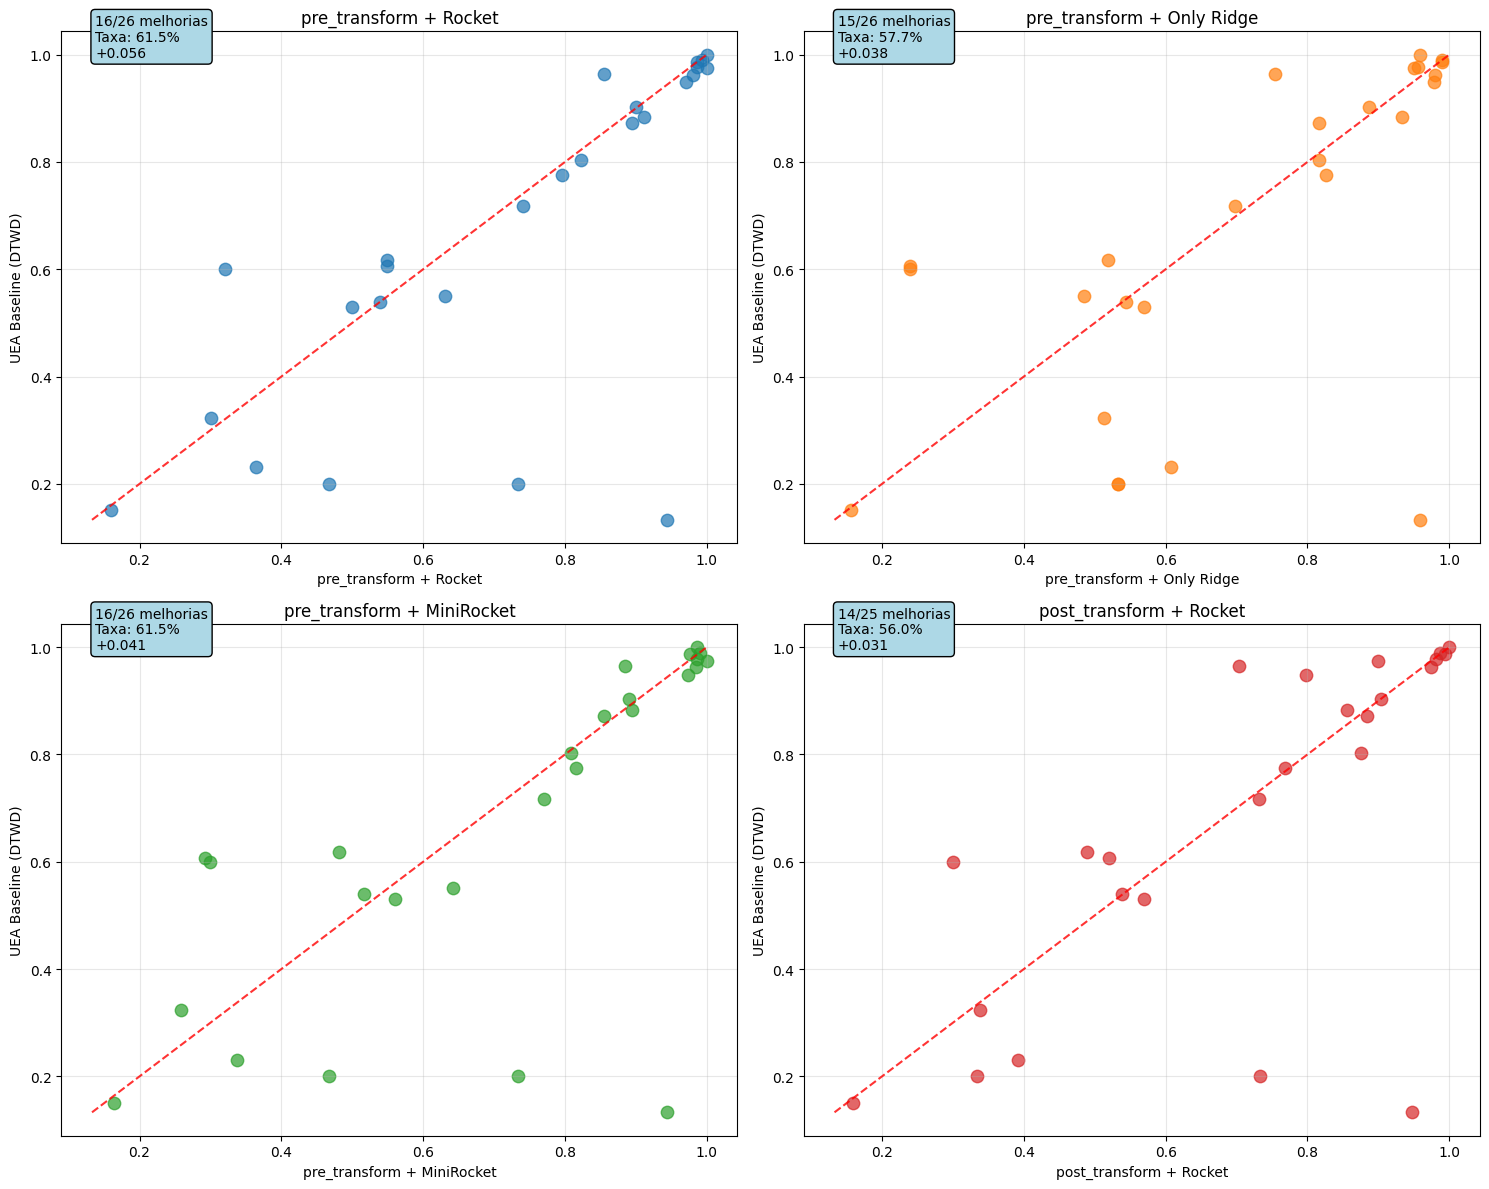


Resumo Final - Comparação das Top Combinações com UEA Baseline:
                   Combinacao  Datasets  Melhorias  Taxa_Melhorias  \
0      pre_transform + Rocket        26         16           0.615   
2  pre_transform + MiniRocket        26         16           0.615   
1  pre_transform + Only Ridge        26         15           0.577   
3     post_transform + Rocket        25         14           0.560   

   Melhoria_Media  
0           0.056  
2           0.041  
1           0.038  
3           0.031  

🏆 MELHOR COMBINAÇÃO GERAL:
   pre_transform + Rocket
   Taxa de melhoria: 61.5%
   Melhoria média: +0.0558
   Datasets melhorados: 16/26


In [ ]:
def compare_combination_with_uea(concat_type, conv_alg, baseline_column='unnormalised_dtwd'):
    """Compara uma combinação específica com o baseline UEA"""
    
    if conv_alg == 'Only Ridge':
        our_data = df[(df['concatenation_type'] == concat_type) & 
                     (df['convolution_algorithm'].isna() | (df['convolution_algorithm'] == ''))]
    else:
        our_data = df[(df['concatenation_type'] == concat_type) & 
                     (df['convolution_algorithm'] == conv_alg)]
    
    if len(our_data) == 0:
        return None, None
    
    our_best = our_data.groupby('dataset')['accuracy'].max().reset_index()
    
    baseline_results = df_baseline[['dataset', baseline_column]].copy()
    baseline_results.columns = ['dataset', 'baseline_accuracy']
    
    comparison = our_best.merge(baseline_results, on='dataset', how='inner')
    
    if len(comparison) == 0:
        return None, None
    
    wins = (comparison['accuracy'] > comparison['baseline_accuracy']).sum()
    total = len(comparison)
    improvement = comparison['accuracy'].mean() - comparison['baseline_accuracy'].mean()
    
    return comparison, {
        'wins': wins,
        'total': total,
        'win_rate': wins/total,
        'improvement': improvement
    }

if len(combinations_df) > 0:
    combo_summary = combinations_df.groupby(['Concatenacao', 'Convolucao'])['Mean'].agg(['count', 'mean']).round(4)
    combo_summary = combo_summary.sort_values('mean', ascending=False)
    
    print("Ranking das Combinações (Concatenação + Convolução):")
    print(combo_summary)
    
    top_combinations = combo_summary.head(4).index.tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    comparison_results = []
    
    for i, (concat_type, conv_alg) in enumerate(top_combinations):
        comparison, stats = compare_combination_with_uea(concat_type, conv_alg)
        
        if comparison is not None:
            ax = axes[i]
            
            ax.scatter(comparison['accuracy'], comparison['baseline_accuracy'], 
                      alpha=0.7, s=80, color=f'C{i}')
            
            min_acc = min(comparison['accuracy'].min(), comparison['baseline_accuracy'].min())
            max_acc = max(comparison['accuracy'].max(), comparison['baseline_accuracy'].max())
            ax.plot([min_acc, max_acc], [min_acc, max_acc], 'r--', alpha=0.8)
            
            ax.set_xlabel(f'{concat_type} + {conv_alg}')
            ax.set_ylabel('UEA Baseline (DTWD)')
            ax.set_title(f'{concat_type} + {conv_alg}')
            ax.grid(True, alpha=0.3)
            
            ax.text(0.05, 0.95, f"{stats['wins']}/{stats['total']} melhorias\n"
                               f"Taxa: {stats['win_rate']:.1%}\n"
                               f"+{stats['improvement']:.3f}", 
                   transform=ax.transAxes, 
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
            
            comparison_results.append({
                'Combinacao': f"{concat_type} + {conv_alg}",
                'Datasets': stats['total'],
                'Melhorias': stats['wins'],
                'Taxa_Melhorias': stats['win_rate'],
                'Melhoria_Media': stats['improvement']
            })
    
    plt.tight_layout()
    plt.show()
    
    if comparison_results:
        final_df = pd.DataFrame(comparison_results)
        print("\nResumo Final - Comparação das Top Combinações com UEA Baseline:")
        print(final_df.sort_values('Taxa_Melhorias', ascending=False).round(3))
        
        best_combo = final_df.loc[final_df['Taxa_Melhorias'].idxmax()]
        print(f"\nMELHOR COMBINAÇÃO GERAL:")
        print(f"   {best_combo['Combinacao']}")
        print(f"   Taxa de melhoria: {best_combo['Taxa_Melhorias']:.1%}")
        print(f"   Melhoria média: +{best_combo['Melhoria_Media']:.4f}")
        print(f"   Datasets melhorados: {best_combo['Melhorias']}/{best_combo['Datasets']}")

else:
    print("Não foi possível gerar análise de combinações.")

## Síntese dos Resultados

Consolidação das principais descobertas do experimento. Identifica a melhor configuração geral e quantifica o impacto de cada componente da pipeline na performance final.

In [ ]:
print("="*60)
print("ANÁLISE FINAL DOS RESULTADOS")
print("="*60)

print("\n1. MELHOR COMBINAÇÃO DE CONCATENAÇÃO E CONVOLUÇÃO:")
concat_conv_performance = df.groupby(['concatenation_type', 'convolution_algorithm'])['accuracy'].agg(['count', 'mean', 'std']).round(4)
print(concat_conv_performance.sort_values('mean', ascending=False))

print("\n2. PERFORMANCE DAS REPRESENTAÇÕES (Pre-Transform + Rocket):")
best_config = df[(df['concatenation_type'] == 'pre_transform') & 
                 (df['convolution_algorithm'] == 'Rocket')]

if len(best_config) > 0:
    rep_performance = best_config.groupby('representation')['accuracy'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
    print(rep_performance.sort_values('mean', ascending=False))
    
    best_representation = rep_performance['mean'].idxmax()
    print(f"\n3. MELHOR REPRESENTAÇÃO: {best_representation}")
    print(f"   Acurácia média: {rep_performance.loc[best_representation, 'mean']:.4f}")

print("\n4. IMPACTO DA CONVOLUÇÃO:")
with_conv = df[df['convolution_algorithm'].isin(['Rocket', 'MiniRocket'])]['accuracy'].mean()
without_conv = df[~df['convolution_algorithm'].isin(['Rocket', 'MiniRocket'])]['accuracy'].mean()

print(f"   Média com convolução: {with_conv:.4f}")
print(f"   Média sem convolução: {without_conv:.4f}")
print(f"   Melhoria: {with_conv - without_conv:.4f}")

print("\n" + "="*60)

ANÁLISE FINAL DOS RESULTADOS

1. MELHOR COMBINAÇÃO DE CONCATENAÇÃO E CONVOLUÇÃO:
                                          count    mean     std
concatenation_type convolution_algorithm                       
pre_transform      Rocket                   162  0.6385  0.2838
                   MiniRocket               162  0.6236  0.2841
post_transform     Rocket                   156  0.6037  0.2681
                   MiniRocket               156  0.5815  0.2711

2. PERFORMANCE DAS REPRESENTAÇÕES (Pre-Transform + Rocket):
                count    mean     std     min     max
representation                                       
GADF               27  0.6762  0.3001  0.1408  1.0000
FIRTS              27  0.6725  0.2918  0.1498  0.9903
CWT                27  0.6597  0.2931  0.1245  1.0000
GASF               27  0.6487  0.2812  0.1419  0.9882
MTF                27  0.5883  0.2690  0.0906  0.9617
RP                 27  0.5854  0.2785  0.1306  0.9770

3. MELHOR REPRESENTAÇÃO: GADF
   Acurácia